<a href="https://colab.research.google.com/github/Halgratir/Gacha-Games/blob/main/Gacha_Games.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import CSV

In [176]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

**Load Data**

In [178]:
gacha_df = pd.read_csv('/content/Gacha_Games - Sheet 1.csv')
gacha_df.head(10)

,Game_Title,Art_Style,Gacha_Type,Status,Monthly_F2P_Pull_Income,Currency_Cost_Per_Pull_USD,Banner_Duration,Platform,Region,Probability_Highest_Rate,Hard_Pity,Hard_Pity_Count,Soft_Pity,Monthly_Downloads,Lifetime_Downloads,Highest_Revenue_Monthly,Lowest_Revenue_Monthly,Age_Rating,Developers
0,100 Sleeping Princes and the Kingdom of Dreams,Anime 2D,Characters,Active,50,2.50,14,"Android, iOS","Japan, China, Taiwan, Korea",0.0350,Yes,No,No,"15,000","12,000,000","5,000,000","120,000",12,GCREST Inc.
1,2.5 Dimensional Seduction: Angels on Stage,Anime 3D,Characters,Service Ending,50,2.20,14,"Android, iOS, PC",Japan,0.0300,Yes,200,Yes,"250,000","2,000,000","2,000,000","20,000",17,Team CARAVAN
2,Compass,Anime 3D,Characters,Active,50,2.00,14,"Android, iOS",Japan,0.0100,No,No,No,"20,000","15,000,000","3,000,000","800,000",12,NHN PlayArt Co. Ltd.
3,ABYSSDIA,Anime 2D,"Characters, Artifacts",Active,50,2.25,14,"Android, iOS, PC","Japan, Global",0.0300,Yes,No,No,"30,000","5,000,000","40,000","5,000",12,"Ring Games Co,. Ltd"
4,Action Tamarin,Anime 3D,"Characters, Supporters",Active,50,2.25,14,"Android, iOS, PC, Nintendo Switch","Japan, Global",0.0300,Yes,100,No,"25,000","3,000,000","800,000","120,000",17,Gremory Games
5,Aether Gazer,Anime 3D,"Characters, Modifiers",Active,70,2.00,21,"Android, iOS, PC","China, Global",0.0160,Yes,140,Yes,"80,000","5,000,000","2,100,000","274,000",12,Yongshi
6,AFK Arena,Stylized 2D,Heroes,Active,80,2.50,14,"Android, iOS",Global,0.0461,Yes,No,No,"40,000","50,000,000","105,400,000","2,000,000",12,Lilith Games
7,AFK Journey,Stylized 3D,Heroes,Active,65,2.25,21,"Android, iOS, PC",Global,0.0205,Yes,40,Yes,"1,200,000","18,000,000","71,800,000","2,590,000",12,Lilith Games
8,Age of Ishtaria,Anime 2D,Cards,Active,50,2.25,14,"Android, iOS, PC","Japan, North America",0.0200,No,No,No,"5,000","5,000,000","1,000,000","30,000",12,Silicon Studio
9,Alchemy Stars,Anime 2D,Characters,Closed,55,2.30,14,"Android, iOS, PC","Global, China",0.0200,Yes,270,No,"50,000","15,000,000","8,000,000","150,000",12,Tourdog Studio


In [179]:
print(f"Dataset Dimensions: {gacha_df.shape}")
gacha_df.info()

Dataset Dimensions: (416, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 416 entries, 0 to 415
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Game_Title                  416 non-null    object 
 1   Art_Style                   416 non-null    object 
 2   Gacha_Type                  414 non-null    object 
 3   Status                      416 non-null    object 
 4   Monthly_F2P_Pull_Income     416 non-null    int64  
 5   Currency_Cost_Per_Pull_USD  416 non-null    float64
 6   Banner_Duration             416 non-null    int64  
 7   Platform                    416 non-null    object 
 8   Region                      368 non-null    object 
 9   Probability_Highest_Rate    416 non-null    float64
 10  Hard_Pity                   416 non-null    object 
 11  Hard_Pity_Count             416 non-null    object 
 12  Soft_Pity                   416 non-null    object 
 13  Month

Success! It reads

If the preview does not load on my github repo. Here is the link to view it: https://nbviewer.org/

**Transform the data**

In [192]:
df = pd.read_csv('/content/Gacha_Games - Sheet 1.csv')

# Transform commas and convert to numeric for 'Monthly_Downloads'
df['Monthly_Downloads'] = df['Monthly_Downloads'].astype(str).str.replace(',', '', regex=False)
df['Monthly_Downloads'] = pd.to_numeric(df['Monthly_Downloads'], errors='coerce')

# Transform commas and convert to numeric for 'Lifetime_Downloads'
df['Lifetime_Downloads'] = df['Lifetime_Downloads'].astype(str).str.replace(',', '', regex=False)
df['Lifetime_Downloads'] = pd.to_numeric(df['Lifetime_Downloads'], errors='coerce')

Handling missing values

In [193]:
#handling missing values
df['Monthly_Downloads'] = df['Monthly_Downloads'].fillna(df['Monthly_Downloads'].median())
df['Lifetime_Downloads'] = df['Lifetime_Downloads'].fillna(df['Lifetime_Downloads'].median())

WE MUST CLEAN

In [205]:
#cleaning 'hard pity count' change 'no' to 0
df['Hard_Pity_Count'] = pd.to_numeric(df['Hard_Pity_Count'].replace('No', 0), errors='coerce').fillna(0)
# Clean 'Highest_Revenue_Monthly' and 'Lowest_Revenue_Monthly'
for col in ['Highest_Revenue_Monthly', 'Lowest_Revenue_Monthly']:
  df[col] = df[col].astype(str).str.replace(',', '', regex=False)
  df[col] = pd.to_numeric(df[col], errors='coerce')

DECODE.......

In [196]:
#encoding analysis
df['Hard_Pity_Count'] = pd.to_numeric(df['Hard_Pity_Count'].replace('No', 0), errors='coerce').fillna(0)

encode careforical variables for ANALYSIS

In [197]:
df['Is_Active'] = df['Status'].apply(lambda x: 1 if x == 'Active' else 0)
print((df.info))
df.head()

<bound method DataFrame.info of                                          Game_Title Art_Style  \
0    100 Sleeping Princes and the Kingdom of Dreams  Anime 2D   
1        2.5 Dimensional Seduction: Angels on Stage  Anime 3D   
2                                           Compass  Anime 3D   
3                                          ABYSSDIA  Anime 2D   
4                                    Action Tamarin  Anime 3D   
..                                              ...       ...   
411                                      XXL WOOFIA  Anime 2D   
412                                    Yoka Legends  Anime 2D   
413           Zatch Bell Companions of Eternal Bond  Anime 2D   
414                               Zenless Zone Zero  Anime 3D   
415                                       Zone Nova  Anime 2D   

                 Gacha_Type          Status  Monthly_F2P_Pull_Income  \
0                Characters          Active                       50   
1                Characters  Service Ending

,Game_Title,Art_Style,Gacha_Type,Status,Monthly_F2P_Pull_Income,Currency_Cost_Per_Pull_USD,Banner_Duration,Platform,Region,Probability_Highest_Rate,Hard_Pity,Hard_Pity_Count,Soft_Pity,Monthly_Downloads,Lifetime_Downloads,Highest_Revenue_Monthly,Lowest_Revenue_Monthly,Age_Rating,Developers,Is_Active
0,100 Sleeping Princes and the Kingdom of Dreams,Anime 2D,Characters,Active,50,2.50,14,"Android, iOS","Japan, China, Taiwan, Korea",0.035,Yes,0,No,15000.0,12000000.0,"5,000,000","120,000",12,GCREST Inc.,1
1,2.5 Dimensional Seduction: Angels on Stage,Anime 3D,Characters,Service Ending,50,2.20,14,"Android, iOS, PC",Japan,0.030,Yes,200,Yes,250000.0,2000000.0,"2,000,000","20,000",17,Team CARAVAN,0
2,Compass,Anime 3D,Characters,Active,50,2.00,14,"Android, iOS",Japan,0.010,No,0,No,20000.0,15000000.0,"3,000,000","800,000",12,NHN PlayArt Co. Ltd.,1
3,ABYSSDIA,Anime 2D,"Characters, Artifacts",Active,50,2.25,14,"Android, iOS, PC","Japan, Global",0.030,Yes,0,No,30000.0,5000000.0,"40,000","5,000",12,"Ring Games Co,. Ltd",1
4,Action Tamarin,Anime 3D,"Characters, Supporters",Active,50,2.25,14,"Android, iOS, PC, Nintendo Switch","Japan, Global",0.030,Yes,100,No,25000.0,3000000.0,"800,000","120,000",17,Gremory Games,1


Object Orient Programming

In [207]:
#a class to represent the gacha game
class GachaGame:
  def __init__(self, title, revenue, downloads):
    self.title = title
    self.revenue = revenue
    self.downloads = downloads

  def calculate_efficiency(self):
    if self.downloads == 0:
      return 0
    return self.revenue / self.downloads

#examples of creating objects from the class
sample_games = []
for index, row in df.head(20).iterrows():
  game = GachaGame(row['Game_Title'], row['Highest_Revenue_Monthly'], row['Monthly_Downloads'])
  sample_games.append(game)

#print efficiency
for g in sample_games:
  print(f"Game: {g.title} | Efficiency: ${g.calculate_efficiency():.2f} per download")

Game: 100 Sleeping Princes and the Kingdom of Dreams | Efficiency: $333.33 per download
Game: 2.5 Dimensional Seduction: Angels on Stage | Efficiency: $8.00 per download
Game: Compass | Efficiency: $150.00 per download
Game: ABYSSDIA | Efficiency: $1.33 per download
Game: Action Tamarin | Efficiency: $32.00 per download
Game: Aether Gazer | Efficiency: $26.25 per download
Game: AFK Arena | Efficiency: $2635.00 per download
Game: AFK Journey | Efficiency: $59.83 per download
Game: Age of Ishtaria | Efficiency: $200.00 per download
Game: Alchemy Stars | Efficiency: $160.00 per download
Game: Alice Closet | Efficiency: $100.00 per download
Game: Alice Gear Aegis | Efficiency: $100.00 per download
Game: Alice Order | Efficiency: $0.00 per download
Game: Alien Egg | Efficiency: $60.00 per download
Game: AlternaVvelt Blue Exorcist AS | Efficiency: $6.00 per download
Game: Anchor Panic | Efficiency: $3.00 per download
Game: Animal Crossing Pocket Camp | Efficiency: $790.00 per download
Game: 

**Utility Function**

In [208]:
def categorize_generosity(prob):
  if prob >= 0.03:
        return 'Generous'
  elif prob >= 0.01:
        return 'Standard'
  else:
        return 'Strict'
df['Generosity_Level'] = df['Probability_Highest_Rate'].apply(categorize_generosity)
print(df[['Game_Title', 'Probability_Highest_Rate', 'Generosity_Level']].head())

                                       Game_Title  Probability_Highest_Rate  \
0  100 Sleeping Princes and the Kingdom of Dreams                     0.035   
1      2.5 Dimensional Seduction: Angels on Stage                     0.030   
2                                         Compass                     0.010   
3                                        ABYSSDIA                     0.030   
4                                  Action Tamarin                     0.030   

  Generosity_Level  
0         Generous  
1         Generous  
2         Standard  
3         Generous  
4         Generous  


Statistical Analysis
analyzing numeric variables to identify potential predictions for revenue

In [211]:
# Statistical summary of numeric columns
print("Summary Statistics:")
print(df[['Monthly_F2P_Pull_Income', 'Probability_Highest_Rate', 'Highest_Revenue_Monthly', 'Monthly_Downloads']].describe())

# Correlation Matrix
correlation_matrix = df[['Highest_Revenue_Monthly', 'Monthly_Downloads', 'Probability_Highest_Rate', 'Monthly_F2P_Pull_Income', 'Currency_Cost_Per_Pull_USD']].corr()
print("\nCorrelation with Highest Monthly Revenue:")
print(correlation_matrix['Highest_Revenue_Monthly'].sort_values(ascending=False))

Summary Statistics:
       Monthly_F2P_Pull_Income  Probability_Highest_Rate  \
count               416.000000                416.000000   
mean                 52.175481                  0.029601   
std                  12.635405                  0.015682   
min                  25.000000                  0.005000   
25%                  50.000000                  0.020000   
50%                  50.000000                  0.030000   
75%                  50.000000                  0.030000   
max                 150.000000                  0.140000   

       Highest_Revenue_Monthly  Monthly_Downloads  
count             4.160000e+02       4.160000e+02  
mean              1.066996e+07       1.792151e+05  
std               2.462188e+07       4.518449e+05  
min               3.500000e+03       0.000000e+00  
25%               1.000000e+06       1.750000e+03  
50%               2.000000e+06       3.000000e+04  
75%               8.000000e+06       1.500000e+05  
max               2.000

Linear Regression

In [214]:
#Prepare the Data
#dropping rows with any remaining NaNs for the regression
reg_data = df[['Highest_Revenue_Monthly', 'Monthly_Downloads', 'Probability_Highest_Rate']].dropna()

X = reg_data[['Monthly_Downloads', 'Probability_Highest_Rate']]
y = reg_data['Highest_Revenue_Monthly']

#split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#create and fit the model
model = LinearRegression()
model.fit(X_train, y_train)

#predictions
y_pred = model.predict(X_test)

#model evaluation
print(f"Model R-squared Score: {r2_score(y_test, y_pred):.4f}")
print(f"Coefficients: {model.coef_}")

Model R-squared Score: 0.2775
Coefficients: [3.15887674e+01 1.87875281e+08]


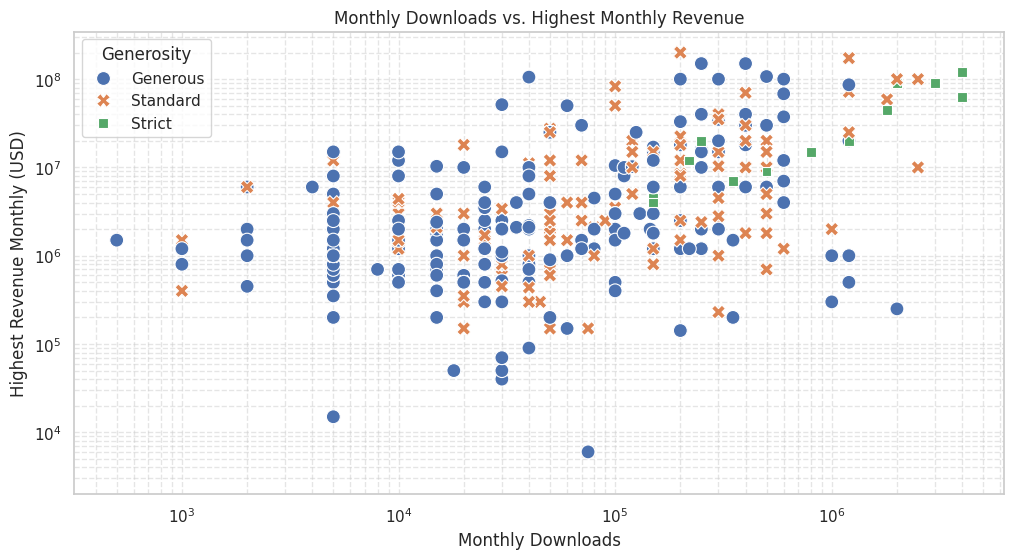

In [217]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='Monthly_Downloads', y='Highest_Revenue_Monthly',
                hue='Generosity_Level', style='Generosity_Level', s=100)

plt.title('Monthly Downloads vs. Highest Monthly Revenue')
plt.xlabel('Monthly Downloads')
plt.ylabel('Highest Revenue Monthly (USD)')
plt.xscale('log') # Using log scale due to high variance in downloads
plt.yscale('log')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(title='Generosity')
plt.savefig('revenue_vs_downloads.png')
plt.show()

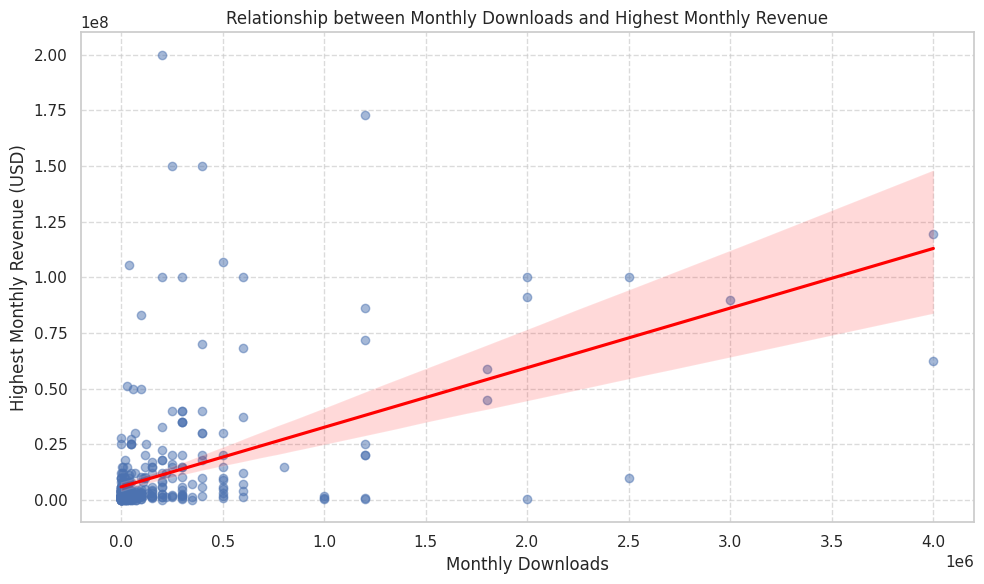

In [216]:
plt.figure(figsize=(10, 6))
sns.regplot(x='Monthly_Downloads', y='Highest_Revenue_Monthly', data=reg_data,
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Relationship between Monthly Downloads and Highest Monthly Revenue')
plt.xlabel('Monthly Downloads')
plt.ylabel('Highest Monthly Revenue (USD)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()